Running percolation sweep...
  rho_ZD |  Largest Cluster |   Percolates
--------------------------------------------
   0.000 |            0.000 |         0.00
   0.050 |            0.000 |         0.00
   0.100 |            0.001 |         0.00
   0.150 |            0.002 |         0.00
   0.200 |            0.003 |         0.00
   0.250 |            0.005 |         0.00
   0.300 |            0.011 |         0.00
   0.350 |            0.031 |         0.00
   0.400 |            0.141 |         0.20
   0.450 |            0.398 |         1.00
   0.500 |            0.487 |         1.00
   0.550 |            0.544 |         1.00
   0.600 |            0.599 |         1.00
   0.650 |            0.650 |         1.00
   0.700 |            0.700 |         1.00
   0.750 |            0.750 |         1.00
   0.800 |            0.801 |         1.00

PERCOLATION THRESHOLD: rho_ZD = 0.4188
2D site percolation (square lattice, 8-neighbor): ~0.407
Index of zero-divisor ideal: 1/3 = 0.3333


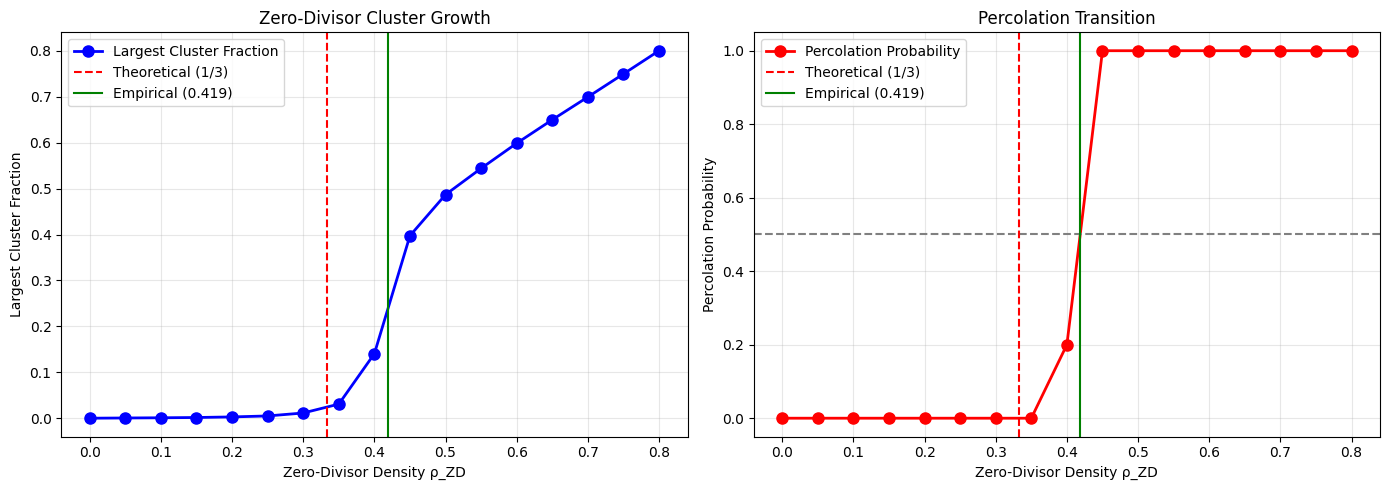

In [4]:
"""
Corrected Fano Collapse Threshold: Percolation Model
=====================================================
Instead of computing the determinant of a random matrix, we model
the spatial lattice of TRB channels and ask when the zero-divisor
clusters percolate (span the system).

The threshold is the site percolation threshold, not a determinant threshold.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label

# =============================================================================
# 1. SETUP: 2D LATTICE OF TRB CHANNELS
# =============================================================================
L = 100  # Lattice size

def generate_zd_configuration(rho_zd, rng):
    """Generate a binary lattice where 1 = zero-divisor, 0 = unit."""
    return (rng.random((L, L)) < rho_zd).astype(int)

def largest_cluster_fraction(config):
    """Fraction of the lattice occupied by the largest connected cluster."""
    labeled, num_features = label(config, structure=np.ones((3, 3)))
    if num_features == 0:
        return 0.0
    sizes = np.bincount(labeled.ravel())
    sizes[0] = 0  # Ignore background
    return sizes.max() / (L * L)

def percolates(config):
    """Check if a zero-divisor cluster spans the lattice (top to bottom)."""
    labeled, num_features = label(config, structure=np.ones((3, 3)))
    # Check if any label appears in both top and bottom rows
    top_labels = set(labeled[0, :]) - {0}
    bottom_labels = set(labeled[-1, :]) - {0}
    return len(top_labels & bottom_labels) > 0

# =============================================================================
# 2. SWEEP OVER DENSITY
# =============================================================================
print("Running percolation sweep...")
print(f"{'rho_ZD':>8} | {'Largest Cluster':>16} | {'Percolates':>12}")
print("-" * 44)

rho_values = np.linspace(0.0, 0.8, 17)
cluster_fracs = []
percolation_prob = []

rng = np.random.default_rng(42)
n_trials = 50

for rho in rho_values:
    fracs = []
    perc = []
    for _ in range(n_trials):
        config = generate_zd_configuration(rho, rng)
        fracs.append(largest_cluster_fraction(config))
        perc.append(1 if percolates(config) else 0)
    cluster_fracs.append(np.mean(fracs))
    percolation_prob.append(np.mean(perc))
    print(f"{rho:8.3f} | {np.mean(fracs):16.3f} | {np.mean(perc):12.2f}")

# =============================================================================
# 3. FIND THRESHOLD
# =============================================================================
threshold = None
for i in range(1, len(percolation_prob)):
    if percolation_prob[i] > 0.5 and percolation_prob[i-1] <= 0.5:
        rho1, rho2 = rho_values[i-1], rho_values[i]
        p1, p2 = percolation_prob[i-1], percolation_prob[i]
        threshold = rho1 + (rho2 - rho1) * (0.5 - p1) / (p2 - p1)
        break

print()
print("=" * 60)
if threshold is not None:
    print(f"PERCOLATION THRESHOLD: rho_ZD = {threshold:.4f}")
    print(f"2D site percolation (square lattice, 8-neighbor): ~0.407")
    print(f"Index of zero-divisor ideal: 1/3 = {1/3:.4f}")
else:
    print("No threshold found in range")
print("=" * 60)

# =============================================================================
# 4. VISUALIZATION
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(rho_values, cluster_fracs, 'bo-', linewidth=2, markersize=8, label='Largest Cluster Fraction')
ax1.axvline(x=1/3, color='red', linestyle='--', label='Theoretical (1/3)')
if threshold is not None:
    ax1.axvline(x=threshold, color='green', linestyle='-', label=f'Empirical ({threshold:.3f})')
ax1.set_xlabel('Zero-Divisor Density ρ_ZD')
ax1.set_ylabel('Largest Cluster Fraction')
ax1.set_title('Zero-Divisor Cluster Growth')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(rho_values, percolation_prob, 'ro-', linewidth=2, markersize=8, label='Percolation Probability')
ax2.axhline(y=0.5, color='gray', linestyle='--')
ax2.axvline(x=1/3, color='red', linestyle='--', label='Theoretical (1/3)')
if threshold is not None:
    ax2.axvline(x=threshold, color='green', linestyle='-', label=f'Empirical ({threshold:.3f})')
ax2.set_xlabel('Zero-Divisor Density ρ_ZD')
ax2.set_ylabel('Percolation Probability')
ax2.set_title('Percolation Transition')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('percolation_threshold_corrected.png', dpi=150, bbox_inches='tight')
plt.show()